In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import requests
import io
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
url = 'https://en.wikipedia.org/wiki/NIFTY_50#Constituents'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

In [3]:
nifty50_df = tables[1]

In [4]:
nifty50_df['Sector[15]'].value_counts()

,count
Sector[15],
Financial Services,11
Automobile and Auto Components,5
Healthcare,5
Information Technology,5
Metals & Mining,4
Fast Moving Consumer Goods,4
"Oil, Gas & Consumable Fuels",3
Power,2
Consumer Durables,2


In [38]:
tickers = nifty50_df['Symbol'].astype('str') + '.NS'
tickers_list = tickers.to_list()

In [39]:
raw_data = yf.download(tickers_list, period='5y', interval='1d')

/tmp/ipykernel_14641/1881955347.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers_list, period='5y', interval='1d')
[*********************100%***********************]  50 of 50 completed


In [40]:
close_prices = raw_data['Close']

In [41]:
close_prices.describe()

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
count,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,...,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,119.000000,1236.000000,1236.000000,1236.000000
mean,2413.943135,1022.203362,5551.352771,2827.190567,976.236132,6092.740643,1647.774596,735.995752,194.807438,1157.905295,...,1239.916307,915.953449,129.293515,3258.569332,1250.709120,2967.592682,360.926051,3085.686781,9019.299770,232.591662
std,648.634245,317.506397,1346.287281,327.476740,200.168258,2659.280217,254.622703,130.150748,129.371928,514.178526,...,409.362623,180.616830,30.312804,402.684081,256.001700,689.980901,28.931616,2079.448309,2258.961958,39.148675
min,1071.796509,455.184814,2942.279785,2109.316650,622.948975,2809.345947,914.258179,438.805206,38.040855,498.669159,...,589.497559,605.125183,73.308022,2356.000000,797.545776,1381.413818,296.200012,706.983276,5062.032715,166.595764
25%,1913.732544,727.710022,4402.922729,2560.109436,782.292160,3480.099976,1519.572632,656.905319,79.507395,717.222168,...,865.723495,749.547867,102.753338,2971.419739,1004.504791,2445.070251,345.325012,1219.747040,7033.868652,194.103836
50%,2385.459229,867.255493,5174.012695,2881.656738,988.074158,4907.673340,1632.181458,709.696625,134.414360,911.655701,...,1114.495300,875.998383,123.637856,3168.256470,1237.458191,3099.251221,359.200012,2071.433105,8289.509766,234.876076
75%,2919.147095,1361.992737,6893.263550,3077.501221,1155.475006,8708.748047,1817.636993,776.455673,296.546280,1629.390900,...,1671.046173,1103.269836,154.102512,3462.155273,1463.815063,3515.794312,379.650009,4970.644165,11334.292725,256.892677
max,4159.593750,1582.451172,8001.377441,3460.254883,1403.000000,12353.318359,2176.600098,1094.150024,468.450012,2162.699951,...,1918.210327,1243.694458,215.520004,4311.585449,1768.400024,4505.000000,417.000000,8227.822266,13052.000000,333.296631


In [43]:
close_prices = close_prices.dropna(axis=1)

In [44]:
log_returns = np.log(close_prices/close_prices.shift(1)).dropna()

In [45]:
log_returns.describe()

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,...,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,0.000540,0.000578,0.000752,-0.000043,0.000614,0.000934,0.000553,0.000598,0.001987,0.001066,...,0.001183,0.000836,0.000446,0.000839,-0.000099,0.000406,0.000897,0.001386,0.000489,0.000020
std,0.031640,0.024016,0.016967,0.014290,0.015366,0.015146,0.017107,0.017975,0.020484,0.013862,...,0.022101,0.012890,0.014509,0.020232,0.013244,0.016988,0.015152,0.021574,0.014634,0.016268
min,-0.331244,-0.237619,-0.083644,-0.085265,-0.078719,-0.138006,-0.073423,-0.080422,-0.220675,-0.067961,...,-0.104269,-0.046596,-0.072249,-0.134826,-0.072714,-0.068577,-0.074513,-0.159873,-0.067659,-0.096783
25%,-0.010253,-0.009281,-0.007706,-0.006879,-0.007826,-0.007105,-0.008530,-0.008657,-0.009191,-0.006762,...,-0.011015,-0.006518,-0.007109,-0.009095,-0.007001,-0.009240,-0.007352,-0.009817,-0.007994,-0.008484
50%,0.000706,0.000203,-0.000008,0.000071,0.000579,0.000771,0.000265,0.000358,0.000935,0.000254,...,0.000690,0.000642,0.000347,0.000830,-0.000286,0.000224,0.000462,0.000986,0.000514,0.000090
75%,0.011846,0.010911,0.008556,0.007060,0.008604,0.008739,0.009012,0.009410,0.013065,0.008447,...,0.013112,0.007688,0.008854,0.010844,0.006871,0.009823,0.008818,0.012373,0.008383,0.008641
max,0.182650,0.142383,0.124361,0.081949,0.086426,0.065042,0.095603,0.101066,0.107010,0.067912,...,0.106171,0.096150,0.068593,0.074373,0.064221,0.071678,0.100771,0.172804,0.065786,0.085617


In [46]:
corr_matrix = log_returns.corr()

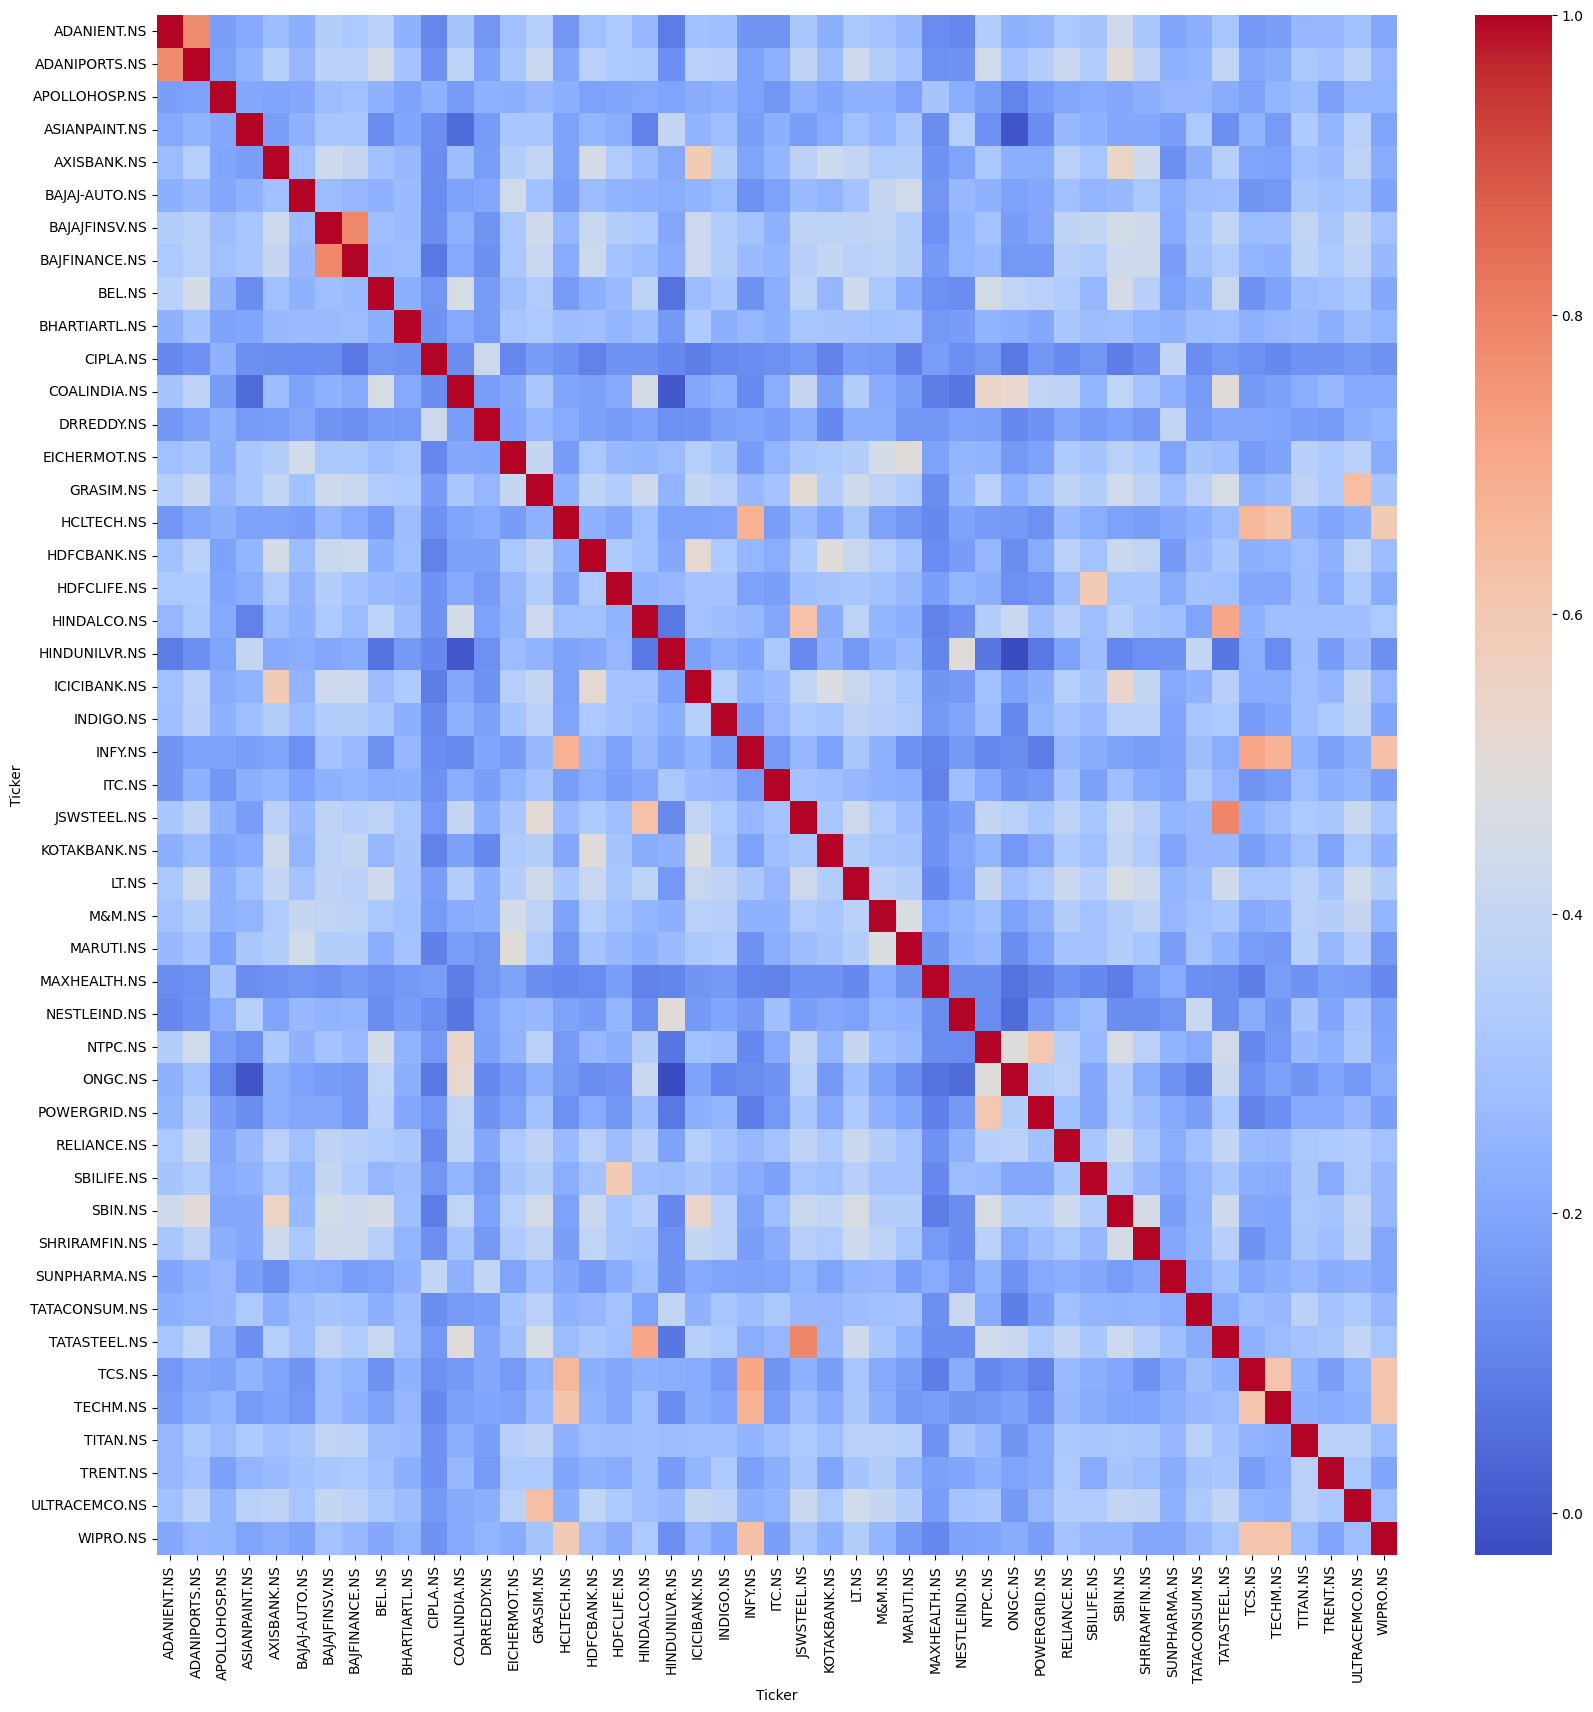

In [47]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

In [48]:
pca = PCA(n_components=10)

In [49]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [50]:
pca.explained_variance_

array([13.55225903,  2.92599424,  2.56387519,  1.81183439,  1.37588454,
        1.29761552,  1.20252096,  1.14786662,  1.0619086 ,  1.03569833])

In [51]:
pca.explained_variance_ratio_

array([0.28811246, 0.06220479, 0.05450637, 0.03851845, 0.02925044,
       0.02758649, 0.02556484, 0.02440292, 0.02257551, 0.02201829])

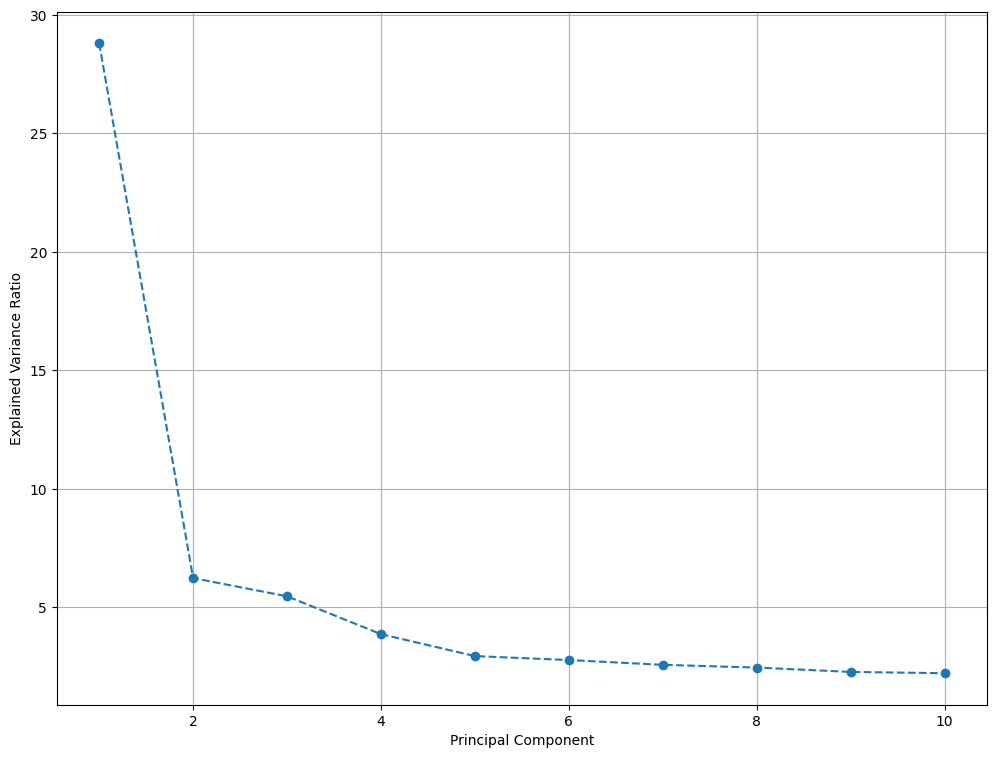

In [52]:
plt.figure(figsize=(12,9))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [53]:
industry_map = (
    nifty50_df[['Symbol', 'Sector[15]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[15]']
)

In [54]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

In [56]:
pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10)['Industry'].value_counts())
display(pc1_sorted.tail(10)['Industry'].value_counts())

,count
Industry,
Financial Services,3
Construction Materials,2
Metals & Mining,2
Construction,1
Services,1
"Oil, Gas & Consumable Fuels",1


,count
Industry,
Healthcare,5
Fast Moving Consumer Goods,3
Consumer Durables,1
"Oil, Gas & Consumable Fuels",1


In [57]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

In [58]:
display(pc2_sorted.head(10)['Industry'].value_counts())
display(pc2_sorted.tail(10)['Industry'].value_counts())

,count
Industry,
Information Technology,5
Fast Moving Consumer Goods,3
Consumer Durables,1
Healthcare,1


,count
Industry,
Financial Services,2
Metals & Mining,2
Power,2
"Oil, Gas & Consumable Fuels",2
Services,1
Capital Goods,1


In [59]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

In [60]:
display(pc3_sorted.head(10)['Industry'].value_counts())
display(pc3_sorted.tail(10)['Industry'].value_counts())

,count
Industry,
Information Technology,5
"Oil, Gas & Consumable Fuels",2
Metals & Mining,2
Power,1


,count
Industry,
Automobile and Auto Components,4
Fast Moving Consumer Goods,3
Financial Services,2
Consumer Durables,1
